# 第 1 关 · 第一滴血

用一个数字预测碱基。这是整个项目最蠢的模型，但它已经是一个逆向设计模型了：
输入结构信息（这个核苷酸周围挤不挤），输出碱基。
后面六关做的全部事情，是把「输入」这一端换得越来越好。

**BOSS：恢复率 > 基准线 + 1.5 个百分点**

---

**这一关有 6 个部分：**

0. 准备
1. 看数据：一条 RNA 在程序里长什么样
2. PyTorch 只学这五样
3. 两条基准线：不先立规矩，涨多少都没意义
4. 搭模型，训练
5. 它到底学到了什么？然后打 BOSS

## 部分 0 · 准备

确认环境和数据都在。数据在外置盘上，盘没插这一格就会报错。

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "minif").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("仓库根：", ROOT)

from minif.plotting import setup
plt = setup()

仓库根： /Users/bf/Documents/GitHub/rna-protein-inverse-folding


In [4]:
import numpy as np
import torch
import torch.nn as nn

from minif import data, features as F, paths, scoreboard

MOL = "rna"
print(paths.describe())

数据 /Users/bf/Documents/GitHub/rna-protein-inverse-folding/datasets
权重 /Users/bf/Documents/GitHub/rna-protein-inverse-folding/runs
结构缓存 /Users/bf/Documents/GitHub/rna-protein-inverse-folding/pdbs
进度 /Users/bf/Documents/GitHub/rna-protein-inverse-folding/progress.json


In [35]:
tr = data.load(MOL, "train")
va = data.load(MOL, "val")
data.describe(tr, "训练集：")
data.describe(va, "验证集：")

训练集：295 条，长度 30-118（平均 68），总残基 20176，配对 6638 对
验证集：21 条，长度 30-70（平均 45），总残基 941，配对 298 对


In [6]:
import numpy as np
z = np.load(data.path_for(MOL), allow_pickle=True)
print("里面有这些数组：", z.files)
print("一共", len(z["ids"]), "条链")
from collections import Counter
print("划分：", Counter(z["split"].tolist()))
print("第 0 条：", z["ids"][0], z["seqs"][0][:40], z["coords"][0].shape)

里面有这些数组： ['ids', 'seqs', 'coords', 'resnum', 'partner', 'split']
一共 316 条链
划分： Counter({'train': 295, 'val': 21})
第 0 条： 12CI_A GGACGAUAGACUCCGUAAUUCGCGUGGAUAUGGCACGCAG (82, 4, 3)


## 部分 1 · 看数据：一条 RNA 在程序里长什么样

每条链是一个 dict。`coords` 是 `[L, 4, 3]`——L 个核苷酸，每个 4 个骨架原子，
每个原子 3 个坐标。四个原子依次是 P、C4'、C1'、糖苷氮。
`partner` 是配对对象的下标，-1 表示没配对。

In [36]:
r = tr[0]
print("编号  ", r["id"])
print("序列  ", r["seq"])
print("坐标  ", r["coords"].shape, r["coords"].dtype)
print("配对  ", r["partner"][:20], "...")
print()
print("第 0 个核苷酸的四个原子坐标：")
for name, xyz in zip(["P", "C4'", "C1'", "N糖苷"], r["coords"][0]):
    print("  %-6s %8.3f %8.3f %8.3f" % (name, *xyz))

编号   12CI_A
序列   GGACGAUAGACUCCGUAAUUCGCGUGGAUAUGGCACGCAGUCAGGUGUUGGGCACCGUAAAUGUCCCACAUAGUAUCGUCCA
坐标   (82, 4, 3) float32
配对   [80 79 78 77 76 75 74 73 -1 45 -1 -1 44 43 -1 -1 -1 69 -1 38] ...

第 0 个核苷酸的四个原子坐标：
  P         7.179   12.388  -16.451
  C4'       8.481    8.819  -17.471
  C1'      10.037    7.580  -18.729
  N糖苷      11.465    7.827  -18.435


In [5]:
# 用点括号把二级结构画出来，比看一串 -1 直观
def dots(partner):
    return "".join("(" if 0 <= p and p > i else (")" if p >= 0 else ".")
                   for i, p in enumerate(partner))

print(r["seq"])
print(dots(r["partner"]))
print("\n配对 %d 对" % int((r["partner"] >= 0).sum() // 2))

GGACGAUAGACUCCGUAAUUCGCGUGGAUAUGGCACGCAGUCAGGUGUUGGGCACCGUAAAUGUCCCACAUAGUAUCGUCCA
((((((((.(..((...(.(.(((((.(.(.(())))))....)))(.(((((.))..).).).))))))...)))))))).

配对 28 对


In [7]:
len(list("GGACGAUAGACUCCGUAAUUCGCGUGGAUAUGGCACGCAGUCAGGUGUUGGGCACCGUAAAUGUCCCACAUAGUAUCGUCCA"))

82

## 部分 2 · PyTorch 只学这五样

张量形状、`nn.Linear` 的形状规则、`nn.Module`、`nn.CrossEntropyLoss`、训练循环。
**这五样后面六关一行都不会变**，今天花时间在这里是划算的。
反向传播怎么推、自动微分怎么实现——不用学。

解释lin(x)=x @ W.T + b

In [16]:
lin = nn.Linear(768, 2)
print("权重", lin.weight.shape)      # [2, 768]
print("偏置", lin.bias.shape)        # [2]
print("参数量", sum(p.numel() for p in lin.parameters()))   # 2*768 + 2 = 1538

x = torch.randn(3, 768)
手算 = x @ lin.weight.T + lin.bias #lin(x)=x @ W.T + b
print("lin(x) 和手算一样吗：", torch.allclose(lin(x), 手算))   # True
print(手算.shape,手算)

权重 torch.Size([2, 768])
偏置 torch.Size([2])
参数量 1538
lin(x) 和手算一样吗： True
torch.Size([3, 2]) tensor([[ 0.0630,  0.3235],
        [ 0.2599, -0.7401],
        [ 0.2918, -0.3502]], grad_fn=<AddBackward0>)


In [17]:
# 1) 形状。x.shape 是你以后 80% 的调试手段
x = torch.randn(3, 768)
print("x", x.shape)

# 2) nn.Linear(a, b)：要求最后一维是 a，把它换成 b，前面所有维度原样不动
lin = nn.Linear(768, 2)
print("Linear(768,2) 吃 [3,768]   出", lin(x).shape)
print("Linear(768,2) 吃 [2,50,768] 出", lin(torch.randn(2, 50, 768)).shape)

x torch.Size([3, 768])
Linear(768,2) 吃 [3,768]   出 torch.Size([3, 2])
Linear(768,2) 吃 [2,50,768] 出 torch.Size([2, 50, 2])


In [29]:
# 3) nn.Module：__init__ 里声明层，forward 里写怎么过，nn.Module 是个基类。你写 class Tiny(nn.Module) 就是继承它，白拿到一整套「管理参数」的能力——否则这些你得自己写。
class Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 2)

    def forward(self, x):
        return self.fc(x)

m = Tiny()
print(m)
print("参数量", sum(p.numel() for p in m.parameters()))

Tiny(
  (fc): Linear(in_features=4, out_features=2, bias=True)
)
参数量 10


In [25]:
# 4) nn.CrossEntropyLoss：吃 [N, 类别数] 的分数 和 [N] 的整数标签
logits = torch.tensor([[10.0, 0.1, 0.1, 0.1],     # 这一行模型觉得是第 0 类（l,4）；其中4表示acgu
                       [0.1, 0.1, 3.0, 0.1]])    # 这一行模型觉得是第 2 类
y = torch.tensor([0, 2])
print("猜对时 loss =", nn.CrossEntropyLoss()(logits, y).item())# y = [0, 2]
print("猜错时 loss =", nn.CrossEntropyLoss()(logits, torch.tensor([1, 1])).item())# 标签换成 [1, 1]

猜对时 loss = 0.0764656811952591
猜错时 loss = 6.476465702056885


In [26]:
import torch, torch.nn as nn
y = torch.tensor([0])                      # 真实答案固定是 A，不动
for name, z in [("强烈倾向U", [0.1, 0.1, 0.1, 3.0]),
                ("没主意",    [0.0, 0.0, 0.0, 0.0]),
                ("明显倾向A", [2.0, 0.1, 0.1, 0.1]),
                ("强烈倾向A", [5.0, 0.1, 0.1, 0.1])]:
    logits = torch.tensor([z])
    p = torch.softmax(logits, 1)[0, 0]
    print("%-10s 给A的概率 %5.1f%%   loss %.3f"
          % (name, 100*p, nn.CrossEntropyLoss()(logits, y).item()))

强烈倾向U      给A的概率   4.7%   loss 3.053
没主意        给A的概率  25.0%   loss 1.386
明显倾向A      给A的概率  69.0%   loss 0.371
强烈倾向A      给A的概率  97.8%   loss 0.022


In [31]:
# 5) 训练循环就这五行。背下来。
#    out  = model(x)         前向：算预测
#    loss = lossfn(out, y)   算错得多离谱
#    opt.zero_grad()         清掉上一轮的梯度（不清会累加，最经典的坑）
#    loss.backward()         反向：算每个参数该往哪动
#    opt.step()              真的动一下
toy_x = torch.randn(100, 4)
toy_y = (toy_x.sum(1) > 0).long()
tm, opt = Tiny(), None
print(tm)
opt = torch.optim.Adam(tm.parameters(), lr=0.1)
for ep in range(50):
    out = tm(toy_x)
    loss = nn.CrossEntropyLoss()(out, toy_y)
    opt.zero_grad(); loss.backward(); opt.step()
print("玩具任务最后 loss %.3f，正确率 %.0f%%"
      % (loss.item(), 100 * (tm(toy_x).argmax(1) == toy_y).float().mean()))

Tiny(
  (fc): Linear(in_features=4, out_features=2, bias=True)
)
玩具任务最后 loss 0.092，正确率 98%


## 部分 3 · 两条基准线：不先立规矩，涨多少都没意义

RNA 字母表只有 4 个：瞎猜 25%，永远猜最常见的碱基接近 30%。
**这条线很高，别被 30% 的恢复率唬住。** 蛋白那边瞎猜只有 5%，所以 RNA 上
恢复率这个指标偏钝——第 4 关会引入一个诚实得多的指标。

In [52]:
RADII = (14.0,)  # 今天只用一个半径。部分 5 的练习里改成三个
RADII = (10.0, 14.0, 18.0)

def flatten(recs, radii=(10.0, 14.0, 18.0)):
    xs, ys = [], []
    for r in recs:
        nb = F.neighbor_counts(r["coords"][:, F.MOL[MOL]["center"]], radii)  # [L, 3]
        paired = (r["partner"] >= 0).astype("float32")[:, None]              # [L, 1] 配对=1
        xs.append(np.concatenate([nb, paired], axis=1))                      # [L, 4]
        ys.append(F.seq_to_idx(r["seq"], MOL))
    return (torch.tensor(np.concatenate(xs), dtype=torch.float32),
            torch.tensor(np.concatenate(ys), dtype=torch.long))

xtr, ytr = flatten(tr)
xva, yva = flatten(va)
print("x", tuple(xtr.shape), " y", tuple(ytr.shape))

x (20176, 4)  y (20176,)


In [54]:
top, _ = data.baseline(tr, MOL)
base_va = (yva == F.seq_to_idx(top, MOL)[0]).float().mean().item()
print("瞎猜            25.0%")
print("永远猜 %s        %.1f%%   <- 要超过的是这条" % (top, 100 * base_va))

瞎猜            25.0%
永远猜 G        34.9%   <- 要超过的是这条


## 部分 4 · 搭模型，训练

特征 1 维，输出 4 维。整个模型就是 `nn.Linear(1, 4)`，8 个参数。
注意这里用的是全量梯度下降（一次吃全部数据），因为数据小。

In [55]:
model = nn.Linear(xtr.shape[1], F.n_letters(MOL))
lossfn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.05)
print("参数量", sum(p.numel() for p in model.parameters()))

hist = []
for ep in range(1, 301):
    out = model(xtr)
    loss = lossfn(out, ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    if ep % 10 == 0:
        with torch.no_grad():
            hist.append((ep, loss.item(),
                         (model(xtr).argmax(-1) == ytr).float().mean().item(),
                         (model(xva).argmax(-1) == yva).float().mean().item()))

acc = hist[-1][3]
print("验证集恢复率 %.1f%%（基准线 %.1f%%）" % (100 * acc, 100 * base_va))

参数量 20
验证集恢复率 40.9%（基准线 34.9%）


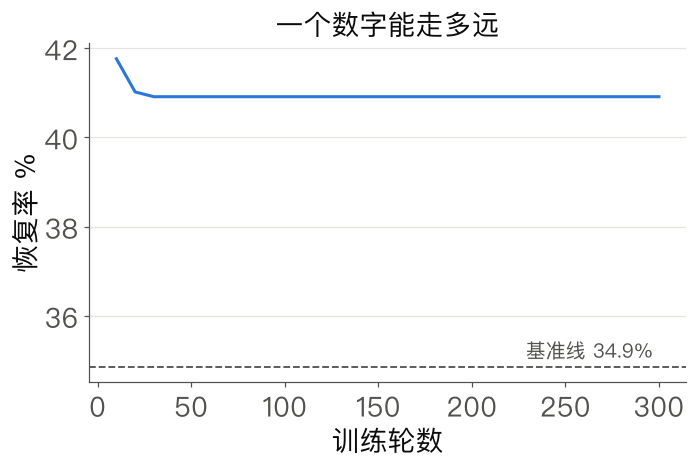

In [56]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "PingFang SC"
plt.rcParams["axes.unicode_minus"] = False
ep, ls, atr, ava = zip(*hist)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ep, [100*a for a in ava], label="验证恢复率")
ax.axhline(100*base_va, color="#52514e", lw=1.2, ls="--")
ax.annotate("基准线 %.1f%%" % (100*base_va), (ep[-1], 100*base_va),
            xytext=(-4, 6), textcoords="offset points", ha="right",
            fontsize=13, color="#52514e")
ax.set_xlabel("训练轮数"); ax.set_ylabel("恢复率 %")
ax.set_title("一个数字能走多远")
from minif.plotting import tidy; tidy(ax)
plt.show()

## 部分 5 · 它到底学到了什么？然后打 BOSS

模型只有 8 个参数，可以直接问它：周围拥挤时偏好哪个碱基，空旷时偏好哪个。
RNA 的茎区是配对且堆叠紧密的，环区松散——想一想 G/C 更该出现在哪。

In [61]:
with torch.no_grad():
    stem = model(torch.tensor([[2.0, 2.5, 3.0, 1.0]]))[0]   # 挤 + 配对
    loop = model(torch.tensor([[1.0, 1.3, 1.6, 0.0]]))[0]   # 松 + 不配对
rank = lambda v: " > ".join(F.alphabet(MOL)[i] for i in v.argsort(descending=True).tolist())
print("茎区偏好：", rank(stem))
print("环区偏好：", rank(loop))

茎区偏好： G > A > U > C
环区偏好： A > G > U > C


In [63]:
with torch.no_grad():
    stem = model(torch.tensor([[2.0, 2.5, 3.0, 1.0]]))[0]   # 配对
    loop = model(torch.tensor([[1.0, 1.3, 1.6, 0.0]]))[0]   # 不配对
rank = lambda v: " > ".join(F.alphabet("rna")[i] for i in v.argsort(descending=True).tolist())
print("茎区偏好：", rank(stem))
print("环区偏好：", rank(loop))

茎区偏好： G > A > U > C
环区偏好： A > G > U > C


In [58]:
scoreboard.record(1, recovery=acc, baseline=base_va)


[记分板] 第 1 关：baseline=0.349  recovery=0.409
[记分板] 挑战 BOSS：python game.py check 1


{'recovery': 0.4091392159461975, 'baseline': 0.34856536984443665}

In [59]:
with torch.no_grad():
    pred = model(xva).argmax(1)
print("模型预测的碱基分布：", torch.bincount(pred, minlength=4).tolist(), "(A C G U)")

# 再看这个特征到底有没有信息：四种碱基的邻居数均值差多少
for i, b in enumerate(F.alphabet(MOL)):
    sel = xtr[ytr == i]
    print("%s  n=%5d  邻居数均值 %.3f ± %.3f" % (b, len(sel), sel.mean(), sel.std()))

模型预测的碱基分布： [345, 1, 595, 0] (A C G U)
A  n= 5080  邻居数均值 0.841 ± 0.692
C  n= 4917  邻居数均值 0.911 ± 0.650
G  n= 6078  邻居数均值 0.904 ± 0.641
U  n= 4101  邻居数均值 0.885 ± 0.675


In [62]:
def build(recs, radii=None, use_pair=False):
    xs, ys = [], []
    for r in recs:
        cols = []
        if radii:
            cols.append(F.neighbor_counts(r["coords"][:, F.MOL[MOL]["center"]], radii))
        if use_pair:
            cols.append((r["partner"] >= 0).astype("float32")[:, None])
        xs.append(np.concatenate(cols, axis=1))
        ys.append(F.seq_to_idx(r["seq"], MOL))
    return (torch.tensor(np.concatenate(xs), dtype=torch.float32),
            torch.tensor(np.concatenate(ys), dtype=torch.long))

def quick_train(xtr, ytr, xva, yva, epochs=300, lr=0.05):
    torch.manual_seed(0)
    m = nn.Linear(xtr.shape[1], F.n_letters(MOL))
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    lossfn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        loss = lossfn(m(xtr), ytr)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        pred = m(xva).argmax(1)
        acc = (pred == yva).float().mean().item()
        n_cls = int((torch.bincount(pred, minlength=4) > 0).sum())
    return acc, n_cls

print("%-26s %-6s %-9s %s" % ("特征", "维度", "恢复率", "预测用到几类"))
for name, kw in [("仅 14Å 邻居数（旧版）",      dict(radii=(14.0,))),
                 ("三个半径邻居数",            dict(radii=(10.0, 14.0, 18.0))),
                 ("仅配对状态",                dict(use_pair=True)),
                 ("三个半径 + 配对（新版）",    dict(radii=(10.0, 14.0, 18.0), use_pair=True))]:
    a, b = build(tr, **kw), build(va, **kw)
    acc, ncls = quick_train(a[0], a[1], b[0], b[1])
    print("%-24s %-8d %-10.1f%% %d" % (name, a[0].shape[1], 100*acc, ncls))

print("\n基准线 %.1f%%" % (100*base_va))

特征                         维度     恢复率       预测用到几类
仅 14Å 邻居数（旧版）            1        34.9      % 1
三个半径邻居数                  3        33.4      % 3
仅配对状态                    1        41.0      % 2
三个半径 + 配对（新版）            4        41.0      % 2

基准线 34.9%


In [60]:
!cd .. && python game.py check 1


  ── 第 1 关 BOSS：第一滴血 ──
  要求：恢复率 > 基准线 + 1.5 个百分点

  ✔ 恢复率 40.9% > 基准线 34.9% + 1.5（现在超出 +6.1 个百分点）

  通过。第 1 关已通关。
  ★ 解锁成就：不看攻略·第1关



## 练习与自测

**练习**：把部分 3 里的 `RADII` 改成 `(10.0, 14.0, 18.0)`，
从那一格往下重跑，看能涨多少。

**自测三问**（对着空气说一遍，说不顺就是没懂）：

1. 逆向设计和正向预测的区别是什么？
2. `nn.Linear(768, 2)` 吃 `[2, 50, 768]` 出什么形状？为什么？
3. `opt.zero_grad()` 不写会怎样？

答完写进 `notes/level1.md`。